In [12]:
"""
MODELO MEJORADO: AttentionResUNet
Combina lo mejor de U-Net, SegNet y añade mejoras modernas:
- Attention Gates para enfocarse en regiones relevantes
- Residual Connections para mejor flujo de gradientes
- Deep Supervision para mejor entrenamiento
- GroupNorm en lugar de BatchNorm
- Arquitectura más profunda y robusta
"""

import torch
import torch.nn as nn
import torch.nn.functional as F



In [13]:

class ResidualBlock(nn.Module):
    """Bloque residual con GroupNorm y ReLU"""
    def __init__(self, in_channels, out_channels, groups=8):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        self.gn1 = nn.GroupNorm(min(groups, out_channels), out_channels)
        self.relu = nn.ReLU(inplace=True)
        
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
        self.gn2 = nn.GroupNorm(min(groups, out_channels), out_channels)
        
        # Shortcut connection
        self.shortcut = nn.Sequential()
        if in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1),
                nn.GroupNorm(min(groups, out_channels), out_channels)
            )
    
    def forward(self, x):
        identity = self.shortcut(x)
        
        out = self.conv1(x)
        out = self.gn1(out)
        out = self.relu(out)
        
        out = self.conv2(out)
        out = self.gn2(out)
        
        out += identity
        out = self.relu(out)
        
        return out


class AttentionGate(nn.Module):
    """
    Attention Gate para enfocarse en regiones relevantes
    Ref: Attention U-Net (Oktay et al. 2018)
    """
    def __init__(self, F_g, F_l, F_int):
        super().__init__()
        
        self.W_g = nn.Sequential(
            nn.Conv2d(F_g, F_int, kernel_size=1, stride=1, padding=0, bias=True),
            nn.GroupNorm(min(8, F_int), F_int)
        )
        
        self.W_x = nn.Sequential(
            nn.Conv2d(F_l, F_int, kernel_size=1, stride=1, padding=0, bias=True),
            nn.GroupNorm(min(8, F_int), F_int)
        )
        
        self.psi = nn.Sequential(
            nn.Conv2d(F_int, 1, kernel_size=1, stride=1, padding=0, bias=True),
            nn.GroupNorm(1, 1),
            nn.Sigmoid()
        )
        
        self.relu = nn.ReLU(inplace=True)
    
    def forward(self, g, x):
        """
        g: gating signal (del decoder)
        x: skip connection (del encoder)
        """
        g1 = self.W_g(g)
        x1 = self.W_x(x)
        
        psi = self.relu(g1 + x1)
        psi = self.psi(psi)
        
        return x * psi


class EncoderBlock(nn.Module):
    """Bloque encoder con residual connections"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.res_block1 = ResidualBlock(in_channels, out_channels)
        self.res_block2 = ResidualBlock(out_channels, out_channels)
        self.pool = nn.MaxPool2d(2, stride=2, return_indices=True)
    
    def forward(self, x):
        x = self.res_block1(x)
        x = self.res_block2(x)
        x_pooled, indices = self.pool(x)
        return x, x_pooled, indices


class DecoderBlock(nn.Module):
    """Bloque decoder con attention gates y residual connections"""
    def __init__(self, in_channels, out_channels, skip_channels):
        super().__init__()
        
        # Upsampling
        self.up = nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2)
        
        # Attention gate
        self.attention = AttentionGate(F_g=out_channels, F_l=skip_channels, F_int=out_channels//2)
        
        # Residual blocks
        self.res_block1 = ResidualBlock(out_channels + skip_channels, out_channels)
        self.res_block2 = ResidualBlock(out_channels, out_channels)
    
    def forward(self, x, skip):
        x = self.up(x)
        
        # Aplicar attention gate a skip connection
        skip = self.attention(g=x, x=skip)
        
        # Concatenar con skip connection
        x = torch.cat([x, skip], dim=1)
        
        x = self.res_block1(x)
        x = self.res_block2(x)
        
        return x


class AttentionResUNet(nn.Module):
    """
    Modelo mejorado para segmentación de vasos sanguíneos
    
    Características:
    - Residual blocks para mejor entrenamiento
    - Attention gates para enfocarse en vasos
    - Deep supervision para múltiples escalas
    - GroupNorm para mejor normalización
    """
    def __init__(self, in_channels=3, num_classes=2, base_ch=64):
        super().__init__()
        
        # Encoder path
        self.enc1 = EncoderBlock(in_channels, base_ch)
        self.enc2 = EncoderBlock(base_ch, base_ch*2)
        self.enc3 = EncoderBlock(base_ch*2, base_ch*4)
        self.enc4 = EncoderBlock(base_ch*4, base_ch*8)
        
        # Bottleneck
        self.bottleneck = nn.Sequential(
            ResidualBlock(base_ch*8, base_ch*16),
            ResidualBlock(base_ch*16, base_ch*16)
        )
        
        # Decoder path con attention
        self.dec4 = DecoderBlock(base_ch*16, base_ch*8, base_ch*8)
        self.dec3 = DecoderBlock(base_ch*8, base_ch*4, base_ch*4)
        self.dec2 = DecoderBlock(base_ch*4, base_ch*2, base_ch*2)
        self.dec1 = DecoderBlock(base_ch*2, base_ch, base_ch)
        
        # Deep supervision outputs (para entrenar mejor)
        self.out_final = nn.Conv2d(base_ch, num_classes, kernel_size=1)
        self.out_dec2 = nn.Conv2d(base_ch*2, num_classes, kernel_size=1)
        self.out_dec3 = nn.Conv2d(base_ch*4, num_classes, kernel_size=1)
    
    def forward(self, x, return_deep_supervision=False):
        """
        Args:
            x: Input image [B, 3, H, W]
            return_deep_supervision: Si True, retorna outputs auxiliares
        
        Returns:
            output: Predicción final [B, num_classes, H, W]
            (opcional) outputs auxiliares para deep supervision
        """
        input_size = x.size()
        
        # Encoder
        skip1, x, idx1 = self.enc1(x)
        skip2, x, idx2 = self.enc2(x)
        skip3, x, idx3 = self.enc3(x)
        skip4, x, idx4 = self.enc4(x)
        
        # Bottleneck
        x = self.bottleneck(x)
        
        # Decoder con attention
        x = self.dec4(x, skip4)
        
        x = self.dec3(x, skip3)
        out3 = self.out_dec3(x)  # Deep supervision
        
        x = self.dec2(x, skip2)
        out2 = self.out_dec2(x)  # Deep supervision
        
        x = self.dec1(x, skip1)
        out_final = self.out_final(x)
        
        if return_deep_supervision:
            # Upsample outputs auxiliares al tamaño original
            out2 = F.interpolate(out2, size=(input_size[2], input_size[3]), 
                                mode='bilinear', align_corners=False)
            out3 = F.interpolate(out3, size=(input_size[2], input_size[3]), 
                                mode='bilinear', align_corners=False)
            return out_final, out2, out3
        
        return out_final


class DeepSupervisionLoss(nn.Module):
    """
    Loss con deep supervision para entrenar mejor
    Combina loss de múltiples escalas
    """
    def __init__(self, weights=[1.0, 0.5, 0.25]):
        super().__init__()
        self.weights = weights
        self.criterion = nn.CrossEntropyLoss()
    
    def forward(self, outputs, target):
        """
        Args:
            outputs: tuple de (out_final, out2, out3)
            target: Ground truth [B, H, W]
        """
        if isinstance(outputs, tuple):
            out_final, out2, out3 = outputs
            
            loss_final = self.criterion(out_final, target)
            loss2 = self.criterion(out2, target)
            loss3 = self.criterion(out3, target)
            
            total_loss = (self.weights[0] * loss_final + 
                         self.weights[1] * loss2 + 
                         self.weights[2] * loss3)
            
            return total_loss
        else:
            return self.criterion(outputs, target)


def count_parameters(model):
    """Cuenta parámetros entrenables del modelo"""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


# Ejemplo de uso
if __name__ == "__main__":
    # Crear modelo
    model = AttentionResUNet(in_channels=3, num_classes=2, base_ch=64)
    
    # Crear tensor de entrada de ejemplo
    x = torch.randn(2, 3, 256, 256)
    
    # Forward pass sin deep supervision
    output = model(x, return_deep_supervision=False)
    print(f"Input shape: {x.shape}")
    print(f"Output shape: {output.shape}")
    
    # Forward pass con deep supervision
    out_final, out2, out3 = model(x, return_deep_supervision=True)
    print(f"\nDeep Supervision:")
    print(f"  Final output: {out_final.shape}")
    print(f"  Output 2: {out2.shape}")
    print(f"  Output 3: {out3.shape}")
    
    print(f"\nParámetros totales: {count_parameters(model):,}")
    print(f"Memoria estimada: ~{count_parameters(model) * 4 / (1024**2):.2f} MB")

Input shape: torch.Size([2, 3, 256, 256])
Output shape: torch.Size([2, 2, 256, 256])

Deep Supervision:
  Final output: torch.Size([2, 2, 256, 256])
  Output 2: torch.Size([2, 2, 256, 256])
  Output 3: torch.Size([2, 2, 256, 256])

Parámetros totales: 64,223,346
Memoria estimada: ~244.99 MB


In [14]:
"""
Script de entrenamiento para AttentionResUNet
Genera archivo .pth con el modelo entrenado
"""

import os
import pickle
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from modelo_mejorado import AttentionResUNet, DeepSupervisionLoss, count_parameters


In [ ]:


# ============================================================================
# DATASET
# ============================================================================

class BloodVesselDataset(Dataset):
    """Dataset para segmentación de vasos sanguíneos"""
    def __init__(self, tile_ids, image_dir, annotations_dict, transform=None):
        self.tile_ids = tile_ids
        self.image_dir = image_dir
        self.annotations = annotations_dict
        self.transform = transform
    
    def __len__(self):
        return len(self.tile_ids)
    
    def __getitem__(self, idx):
        tile_id = self.tile_ids[idx]
        
        # Cargar imagen (simulado - ajusta según tu estructura)
        # Aquí asumo que tienes las imágenes en formato compatible
        image_path = os.path.join(self.image_dir, f"{tile_id}.png")
        
        # NOTA: Ajusta esta parte según cómo cargas tus imágenes
        # Este es un ejemplo genérico
        try:
            from PIL import Image
            image = Image.open(image_path).convert('RGB')
            image = np.array(image)
        except:
            # Si no funciona, crear imagen dummy
            image = np.random.randint(0, 255, (256, 256, 3), dtype=np.uint8)
        
        # Crear máscara desde anotaciones
        mask = self.create_mask(tile_id)
        
        # Aplicar transformaciones
        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']
        
        # Convertir a tensor
        image = torch.from_numpy(image).permute(2, 0, 1).float() / 255.0
        mask = torch.from_numpy(mask).long()
        
        return image, mask, tile_id
    
    def create_mask(self, tile_id):
        """Crea máscara binaria desde anotaciones"""
        import cv2
        
        # Crear máscara 512x512 original
        mask = np.zeros((512, 512), dtype=np.uint8)
        
        if tile_id in self.annotations:
            annotations = self.annotations[tile_id].get('annotations', [])
            
            for ann in annotations:
                if ann.get('type') == 'blood_vessel':
                    coords = ann.get('coordinates', [])
                    
                    if coords and len(coords) > 0:
                        points = np.array(coords[0], dtype=np.int32)
                        cv2.fillPoly(mask, [points], color=1)
        
        # Redimensionar a 256x256
        mask = cv2.resize(mask, (256, 256), interpolation=cv2.INTER_NEAREST)
        
        return mask

# ============================================================================
# DATA AUGMENTATION
# ============================================================================

def get_train_transform():
        return None


def get_val_transform():
    """Transformaciones para validación (sin augmentation)"""
    return None


# ============================================================================
# MÉTRICAS
# ============================================================================

def dice_coefficient(pred, target, smooth=1e-6):
    """Calcula Dice coefficient"""
    pred = torch.sigmoid(pred[:, 1, :, :]) > 0.5  # Clase positiva
    target = target == 1
    
    intersection = (pred & target).float().sum((1, 2))
    union = pred.float().sum((1, 2)) + target.float().sum((1, 2))
    
    dice = (2. * intersection + smooth) / (union + smooth)
    return dice.mean()


def iou_score(pred, target, smooth=1e-6):
    """Calcula IoU (Intersection over Union)"""
    pred = torch.sigmoid(pred[:, 1, :, :]) > 0.5
    target = target == 1
    
    intersection = (pred & target).float().sum((1, 2))
    union = (pred | target).float().sum((1, 2))
    
    iou = (intersection + smooth) / (union + smooth)
    return iou.mean()


# ============================================================================
# ENTRENAMIENTO
# ============================================================================

def train_epoch(model, dataloader, criterion, optimizer, device, use_deep_supervision=True):
    """Entrena una época"""
    model.train()
    
    total_loss = 0
    total_dice = 0
    total_iou = 0
    
    pbar = tqdm(dataloader, desc="Training")
    for images, masks, _ in pbar:
        images = images.to(device)
        masks = masks.to(device)
        
        # Forward pass
        optimizer.zero_grad()
        
        if use_deep_supervision:
            outputs = model(images, return_deep_supervision=True)
            loss = criterion(outputs, masks)
            final_output = outputs[0]
        else:
            outputs = model(images, return_deep_supervision=False)
            loss = criterion(outputs, masks)
            final_output = outputs
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        # Métricas
        with torch.no_grad():
            dice = dice_coefficient(final_output, masks)
            iou = iou_score(final_output, masks)
        
        total_loss += loss.item()
        total_dice += dice.item()
        total_iou += iou.item()
        
        pbar.set_postfix({
            'loss': f'{loss.item():.4f}',
            'dice': f'{dice.item():.4f}',
            'iou': f'{iou.item():.4f}'
        })
    
    return {
        'loss': total_loss / len(dataloader),
        'dice': total_dice / len(dataloader),
        'iou': total_iou / len(dataloader)
    }


def validate_epoch(model, dataloader, criterion, device):
    """Valida una época"""
    model.eval()
    
    total_loss = 0
    total_dice = 0
    total_iou = 0
    
    with torch.no_grad():
        pbar = tqdm(dataloader, desc="Validation")
        for images, masks, _ in pbar:
            images = images.to(device)
            masks = masks.to(device)
            
            # Forward pass
            outputs = model(images, return_deep_supervision=False)
            loss = criterion(outputs, masks)
            
            # Métricas
            dice = dice_coefficient(outputs, masks)
            iou = iou_score(outputs, masks)
            
            total_loss += loss.item()
            total_dice += dice.item()
            total_iou += iou.item()
            
            pbar.set_postfix({
                'loss': f'{loss.item():.4f}',
                'dice': f'{dice.item():.4f}',
                'iou': f'{iou.item():.4f}'
            })
    
    return {
        'loss': total_loss / len(dataloader),
        'dice': total_dice / len(dataloader),
        'iou': total_iou / len(dataloader)
    }


def plot_metrics(history, save_path='training_history.png'):
    """Grafica métricas de entrenamiento"""
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    epochs = range(1, len(history['train_loss']) + 1)
    
    # Loss
    axes[0].plot(epochs, history['train_loss'], 'b-', label='Train')
    axes[0].plot(epochs, history['val_loss'], 'r-', label='Val')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Loss')
    axes[0].legend()
    axes[0].grid(True)
    
    # Dice
    axes[1].plot(epochs, history['train_dice'], 'b-', label='Train')
    axes[1].plot(epochs, history['val_dice'], 'r-', label='Val')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Dice')
    axes[1].set_title('Dice Coefficient')
    axes[1].legend()
    axes[1].grid(True)
    
    # IoU
    axes[2].plot(epochs, history['train_iou'], 'b-', label='Train')
    axes[2].plot(epochs, history['val_iou'], 'r-', label='Val')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('IoU')
    axes[2].set_title('IoU Score')
    axes[2].legend()
    axes[2].grid(True)
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f"✓ Gráfica guardada: {save_path}")


# ============================================================================
# MAIN
# ============================================================================

def main():
    # Configuración
    CONFIG = {
        'data_pkl': 'data_minimal_filtrado.pkl',  # o 'data_minimal.pkl'
        'image_dir': '../train/',
        'batch_size': 2,
        'num_epochs': 2,
        'learning_rate': 1e-4,
        'weight_decay': 1e-5,
        'device': 'cpu',
        'num_workers': 0,
        'save_path': 'AttentionResUNet_best.pth',
        'base_ch': 32,  # Canales base (32, 64, o 128)
        'use_deep_supervision': True,
    }
    
    print("="*70)
    print("ENTRENAMIENTO - AttentionResUNet")
    print("="*70)
    print(f"Device: {CONFIG['device']}")
    print(f"Batch size: {CONFIG['batch_size']}")
    print(f"Epochs: {CONFIG['num_epochs']}")
    print(f"Learning rate: {CONFIG['learning_rate']}")
    print(f"Deep supervision: {CONFIG['use_deep_supervision']}")
    print("="*70)
    
    # Cargar datos
    print("\n📁 Cargando datos...")
    try:
        with open(CONFIG['data_pkl'], 'rb') as f:
            data = pickle.load(f)
        
        train_ids = data['train']
        val_ids = data['val']
        annotations = data['annotations']
        
        print(f"✓ Train: {len(train_ids)} imágenes")
        print(f"✓ Val: {len(val_ids)} imágenes")
    except FileNotFoundError:
        print(f"⚠️ Archivo {CONFIG['data_pkl']} no encontrado")
        print("Creando datos dummy para demostración...")
        train_ids = [f"train_{i}" for i in range(100)]
        val_ids = [f"val_{i}" for i in range(20)]
        annotations = {}
    
    # Crear datasets
    train_dataset = BloodVesselDataset(
        train_ids, 
        CONFIG['image_dir'], 
        annotations,
        transform=get_train_transform()
    )
    
    val_dataset = BloodVesselDataset(
        val_ids,
        CONFIG['image_dir'],
        annotations,
        transform=get_val_transform()
    )
    
    # Crear dataloaders
    train_loader = DataLoader(
        train_dataset,
        batch_size=CONFIG['batch_size'],
        shuffle=True,
        num_workers=CONFIG['num_workers'],
        pin_memory=True if CONFIG['device'] == 'cuda' else False
    )
    
    val_loader = DataLoader(
        val_dataset,
        batch_size=CONFIG['batch_size'],
        shuffle=False,
        num_workers=CONFIG['num_workers'],
        pin_memory=True if CONFIG['device'] == 'cuda' else False
    )
    
    # Crear modelo
    print("\n🏗️ Creando modelo...")
    model = AttentionResUNet(
        in_channels=3,
        num_classes=2,
        base_ch=CONFIG['base_ch']
    ).to(CONFIG['device'])
    
    print(f"✓ Parámetros: {count_parameters(model):,}")
    
    # Loss y optimizer
    if CONFIG['use_deep_supervision']:
        criterion = DeepSupervisionLoss(weights=[1.0, 0.5, 0.25])
    else:
        criterion = nn.CrossEntropyLoss()
    
    optimizer = optim.AdamW(
        model.parameters(),
        lr=CONFIG['learning_rate'],
        weight_decay=CONFIG['weight_decay']
    )
    
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        factor=0.5,
        patience=5,
        # verbose=True
    )
    
    # Entrenamiento
    print("\n🚀 Iniciando entrenamiento...\n")
    
    best_dice = 0
    history = {
        'train_loss': [], 'train_dice': [], 'train_iou': [],
        'val_loss': [], 'val_dice': [], 'val_iou': []
    }
    
    for epoch in range(1, CONFIG['num_epochs'] + 1):
        print(f"\n{'='*70}")
        print(f"Epoch {epoch}/{CONFIG['num_epochs']}")
        print(f"{'='*70}")
        
        # Train
        train_metrics = train_epoch(
            model, train_loader, criterion, optimizer,
            CONFIG['device'], CONFIG['use_deep_supervision']
        )
        
        # Validate
        val_metrics = validate_epoch(
            model, val_loader, criterion, CONFIG['device']
        )
        
        # Update scheduler
        scheduler.step(val_metrics['loss'])
        
        # Guardar métricas
        history['train_loss'].append(train_metrics['loss'])
        history['train_dice'].append(train_metrics['dice'])
        history['train_iou'].append(train_metrics['iou'])
        history['val_loss'].append(val_metrics['loss'])
        history['val_dice'].append(val_metrics['dice'])
        history['val_iou'].append(val_metrics['iou'])
        
        # Print resumen
        print(f"\n📊 Epoch {epoch} Summary:")
        print(f"  Train - Loss: {train_metrics['loss']:.4f} | "
              f"Dice: {train_metrics['dice']:.4f} | IoU: {train_metrics['iou']:.4f}")
        print(f"  Val   - Loss: {val_metrics['loss']:.4f} | "
              f"Dice: {val_metrics['dice']:.4f} | IoU: {val_metrics['iou']:.4f}")
        
        # Guardar mejor modelo
        if val_metrics['dice'] > best_dice:
            best_dice = val_metrics['dice']
            
            # Guardar checkpoint completo
            checkpoint = {
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'scheduler_state_dict': scheduler.state_dict(),
                'best_dice': best_dice,
                'config': CONFIG,
                'history': history
            }
            
            torch.save(checkpoint, CONFIG['save_path'])
            print(f"\n✓ Mejor modelo guardado! Dice: {best_dice:.4f}")
    
    # Guardar gráficas
    print("\n📈 Generando gráficas...")
    plot_metrics(history)
    
    print("\n" + "="*70)
    print("✅ ENTRENAMIENTO COMPLETADO")
    print("="*70)
    print(f"Mejor Dice: {best_dice:.4f}")
    print(f"Modelo guardado: {CONFIG['save_path']}")
    print("="*70)


if __name__ == "__main__":
    main()

ENTRENAMIENTO - AttentionResUNet
Device: cpu
Batch size: 2
Epochs: 2
Learning rate: 0.0001
Deep supervision: True

📁 Cargando datos...
✓ Train: 1173 imágenes
✓ Val: 226 imágenes

🏗️ Creando modelo...
✓ Parámetros: 16,068,674

🚀 Iniciando entrenamiento...


Epoch 1/2


Training:   0%|          | 0/587 [00:01<?, ?it/s]


RuntimeError: size mismatch (got input: [2, 2, 256, 256] , target: [2, 512, 512]

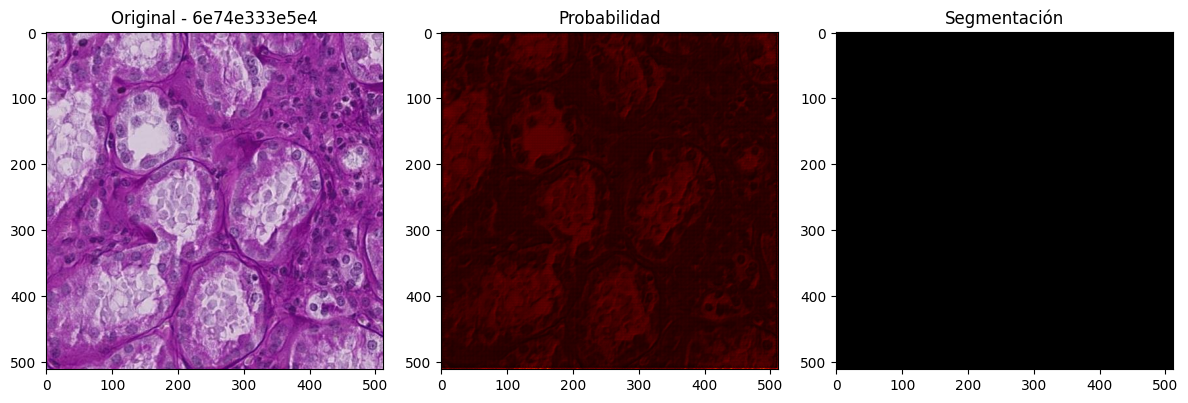

✓ Imagen: 6e74e333e5e4
✓ Vasos: 0 píxeles (0.00%)


In [ ]:
import torch
import numpy as np
import pickle
import os
from PIL import Image
import matplotlib.pyplot as plt
from modelo_mejorado import AttentionResUNet

# Cargar datos
with open('data_minimal_filtrado.pkl', 'rb') as f:
    data = pickle.load(f)

# Tomar primera imagen de ENTRENAMIENTO
tile_id = data['train'][0]
image_path = os.path.join('../train/', f"{tile_id}.tif")  # Cambiado a .tif

# Cargar imagen
image = Image.open(image_path).convert('RGB')
image_np = np.array(image)

# Cargar modelo
checkpoint = torch.load('AttentionResUNet_best.pth', map_location='cpu')
model = AttentionResUNet(in_channels=3, num_classes=2, base_ch=32)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

# Predecir
img_tensor = torch.from_numpy(image_np).permute(2, 0, 1).float() / 255.0
img_tensor = img_tensor.unsqueeze(0)

with torch.no_grad():
    output = model(img_tensor)
    prob = torch.softmax(output, dim=1)[0, 1].numpy()
    mask = (prob > 0.5).astype(np.uint8)

# Mostrar
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(image_np)
axes[0].set_title(f'Original - {tile_id}')
axes[1].imshow(prob, cmap='hot')
axes[1].set_title('Probabilidad')
axes[2].imshow(mask, cmap='gray')
axes[2].set_title('Segmentación')
plt.tight_layout()
plt.savefig('prediccion.png')
plt.show()

print(f"✓ Imagen: {tile_id}")
print(f"✓ Vasos: {mask.sum()} píxeles ({100*mask.mean():.2f}%)")

In [ ]:
print(data['annotations'][data['train'][0]])


{'id': '6e74e333e5e4', 'annotations': [{'type': 'blood_vessel', 'coordinates': [[[435, 175], [434, 175], [433, 175], [432, 175], [431, 175], [430, 175], [429, 175], [429, 174], [428, 174], [427, 174], [427, 173], [426, 173], [426, 172], [425, 172], [425, 171], [425, 170], [425, 169], [426, 168], [426, 168], [427, 167], [427, 167], [428, 166], [428, 166], [429, 165], [430, 165], [430, 165], [431, 164], [431, 164], [432, 163], [432, 163], [433, 162], [433, 162], [434, 161], [434, 161], [435, 160], [436, 160], [437, 160], [438, 160], [438, 161], [439, 161], [439, 162], [439, 163], [439, 164], [439, 165], [439, 166], [439, 166], [438, 167], [438, 168], [438, 169], [438, 170], [438, 170], [437, 171], [437, 172], [437, 173], [437, 173], [436, 174], [436, 174], [435, 175], [435, 175]]]}, {'type': 'blood_vessel', 'coordinates': [[[488, 447], [487, 447], [486, 447], [485, 447], [484, 447], [483, 447], [482, 447], [482, 446], [481, 446], [480, 446], [480, 445], [479, 445], [478, 445], [478, 444]